In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
pd.set_option("future.no_silent_downcasting", True)
 
from laparoscopy_helpers.data_cleaning import to_snake_case, clean_surgical_df
from poor_patient_helpers.data_cleaning import load_all_endo, load_all_mercy, load_all_safe, build_final

In [2]:
TB_orig = pd.read_excel(
    "../Nkhoma_data/theatre_book_data/combined_clean.xlsx",
    engine="openpyxl"
)
path_corrected_names = '../Nkhoma_data/poor_patients_funds_data_corrected_names'
TB = pd.read_excel(
    f"{path_corrected_names}/combined_clean_corrected.xlsx",
    engine="openpyxl"
)
base_path = "../Nkhoma_data/poor_patients_funds_data"
endo  = load_all_endo(f"{base_path}/Endoscopy Ledger")
mercy = load_all_mercy(f"{base_path}/Mercy Fund")
safe  = load_all_safe(f"{base_path}/SAFE")

# ── Run both pipelines ────────────────────────────────────────────────
final_orig = build_final(TB_orig, mercy, safe, endo, verbose=False)
final_corr = build_final(TB,      mercy, safe, endo, verbose=False)

# ── Identify what changed ─────────────────────────────────────────────
orig_unmatched_names = set(
    final_orig[
        (final_orig["match_status"] == "unmatched") &
        (final_orig["unmatched_reason"] == "not_in_TB")
    ]["fund_name"].unique()
)
corr_unmatched_names = set(
    final_corr[
        (final_corr["match_status"] == "unmatched") &
        (final_corr["unmatched_reason"] == "not_in_TB")
    ]["fund_name"].unique()
)
newly_fixed  = orig_unmatched_names - corr_unmatched_names
newly_broken = corr_unmatched_names - orig_unmatched_names

print(f"Originally unmatched (not_in_TB): {len(orig_unmatched_names)}")
print(f"Newly fixed by correction:        {len(newly_fixed)}")
print(f"Newly broken by correction:       {len(newly_broken)}")
print(f"Net change:                       {len(newly_fixed) - len(newly_broken)}")

# ── Merge best of both worlds ─────────────────────────────────────────
orig_matched       = final_orig[final_orig["match_status"] == "matched"].copy()
newly_fixed_matched = final_corr[
    (final_corr["match_status"] == "matched") &
    (final_corr["fund_name"].isin(newly_fixed))
].copy()
still_unmatched    = final_corr[
    (final_corr["match_status"] == "unmatched") &
    (final_corr["fund_name"].isin(orig_unmatched_names - newly_fixed))
].copy()

final = pd.concat(
    [orig_matched, newly_fixed_matched, still_unmatched],
    ignore_index=True
)

print(f"\n── Final (best of both) ──────────────────────────────")
print(f"Original matched:   {len(orig_matched)}")
print(f"Newly fixed added:  {len(newly_fixed_matched)}")
print(f"Still unmatched:    {len(still_unmatched)}")
print(f"Total rows:         {len(final)}")
print(f"\nMatch status by fund:")
print(final.groupby(["fund", "match_status"]).size().unstack(fill_value=0))

✓ endo  22 May               → 14 rows
✓ endo  22 June              → 7 rows
✓ endo  22 Aug               → 14 rows
✓ endo  22 Sept              → 6 rows
✓ endo  22 Oct               → 5 rows
✓ endo  22 Nov               → 7 rows
✓ endo  22 Dec               → 6 rows
✓ endo  23 JAN               → 9 rows
✓ endo  23 FEB               → 11 rows
✓ endo  23 MAR               → 9 rows
✓ endo  23 APR               → 16 rows
✓ endo  23 MAY               → 6 rows
✓ endo  23 SEPT              → 21 rows
✓ endo  23 OCT               → 4 rows
✓ endo  23 NOV               → 14 rows
✓ endo  23 DEC               → 9 rows
✓ endo  2024 FULL LIST       → 124 rows
✓ endo  January              → 15 rows
✓ endo  February             → 15 rows
✓ endo  March                → 20 rows
✓ endo  April                → 20 rows
✓ endo  May                  → 20 rows
✓ endo  June                 → 25 rows
✓ endo  July                 → 20 rows
✓ endo  August               → 28 rows
✓ endo  September            → 27 

/home/mat2m10/code/mat2m10/nkhoma/notebooks/poor_patient_helpers/data_cleaning.py:688: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  links = pd.concat([mercy_links, safe_links, endo_links], ignore_index=True)


Originally unmatched (not_in_TB): 410
Newly fixed by correction:        272
Newly broken by correction:       541
Net change:                       -269

── Final (best of both) ──────────────────────────────
Original matched:   2247
Newly fixed added:  289
Still unmatched:    138
Total rows:         2674

Match status by fund:
match_status  matched  unmatched
fund                            
endo              507          8
mercy            1425        116
safe              604         14


/home/mat2m10/code/mat2m10/nkhoma/notebooks/poor_patient_helpers/data_cleaning.py:688: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  links = pd.concat([mercy_links, safe_links, endo_links], ignore_index=True)


In [3]:
# Redefine matched/unmatched from the best-of-both final
matched  = final[final["match_status"] == "matched"].copy()
unmatched = final[final["match_status"] == "unmatched"].copy()
not_in_TB = unmatched[unmatched["unmatched_reason"] != "outside_TB_range"]

In [4]:
# ═══════════════════════════════════════════════════════════════════════
# SPECIAL CASES & MANUAL FLAGS
# ═══════════════════════════════════════════════════════════════════════

# ── 1. OLASIO — cross-fund duplicate (no patient number) ──────────────
final.loc[
    (final["fund_name"].str.contains("OLASIO", na=False)) &
    (final["patient_number"].isna()),
    "cross_fund_flag"
] = True

olasio = final[final["fund_name"].str.contains("OLASIO", na=False)]
print("=== OLASIO: two fund entries sharing the same TB procedures ===")
print(olasio[["fund_name","patient_number","fund_admission_date","theatre_index"]]
      .drop_duplicates().sort_values("theatre_index").to_string(index=False))
print("\nTB rows 240616 / 240651:")
print(TB[TB["theatre_book_index"].isin([240616, 240651])][
    ["theatre_book_index","date_of_surgery","first_name","last_name",
     "department","final_diagnosis_category","main_procedure_category"]
].to_string(index=False))
print("\nFinancials:")
print(olasio[["fund_name","patient_number","fund_admission_date",
              "total_bill_mk","copay_mk","fund_covered_mk"]]
      .drop_duplicates(subset=["fund_name","fund_admission_date"])
      .to_string(index=False))
# OLASIO ANTONIO (patient 376856) and OLASIO ANTHONYO (no number) are the same person
# ANTHONYO entry has no patient number — manually flagged as cross_fund duplicate

# ── 2. Mercy entries with no patient number ───────────────────────────
nan_mercy = (final[(final["fund"] == "mercy") & (final["patient_number"].isna())]
             .drop_duplicates(subset=["fund_name","fund_admission_date"]))
print(f"\n=== Mercy entries with no patient number: {len(nan_mercy)} ===")
print(nan_mercy[["fund_name","fund_admission_date","total_bill_mk","fund_covered_mk"]]
      .sort_values("fund_admission_date").to_string(index=False))
# 3 entries: LAMECK BIHALE, OLASIO ANTHONYO, HOLLINGS MAONGA — all April 2024

# ── 3. Spot-checks: LAMECK BIHALE & HOLLINGS MAONGA ──────────────────
print("\n=== Spot-checks: LAMECK BIHALE / HOLLINGS MAONGA ===")
for name in ["LAMECK BIHALE", "HOLLINGS MAONGA"]:
    first, last = name.split(" ", 1)
    print(f"\n── {name} ──")
    tb_match = TB[
        TB["first_name"].str.contains(first, na=False, case=False) |
        TB["last_name"].str.contains(last,  na=False, case=False)
    ][["theatre_book_index","date_of_surgery","first_name","last_name",
       "department","final_diagnosis_category"]]
    print("TB:  ", tb_match.to_string(index=False) if len(tb_match) else "no match")
    fund_rows = (final[final["fund_name"].str.contains(first, na=False, case=False)]
                 [["fund","fund_name","patient_number","fund_admission_date",
                   "total_bill_mk","fund_covered_mk"]]
                 .drop_duplicates(subset=["fund","fund_name","fund_admission_date"]))
    print("Fund:", fund_rows.to_string(index=False) if len(fund_rows) else "no match")
# LAMECK BIHALE — no TB match for this exact name; closest is LAMECK YOSEFE (different person)
# HOLLINGS MAONGA — no TB match; MAONGA last name exists but different first names entirely
# Both are likely missing from TB or admitted under a different name — needs manual review

=== OLASIO: two fund entries sharing the same TB procedures ===
      fund_name patient_number fund_admission_date  theatre_index
OLASIO ANTHONYO            NaN          2024-04-05       240534.0
OLASIO ANTHONYO            NaN          2024-04-05       240544.0
 OLASIO ANTONIO         376856          2024-05-13       240616.0
OLASIO ANTHONYO            NaN          2024-04-05       240616.0
 OLASIO ANTONIO         376856          2024-05-13       240651.0
OLASIO ANTHONYO            NaN          2024-04-05       240651.0
 OLASIO ANTONIO         376856          2024-05-13       240732.0
 OLASIO ANTONIO         376856          2024-05-13       240860.0

TB rows 240616 / 240651:
 theatre_book_index date_of_surgery first_name last_name department final_diagnosis_category main_procedure_category
             240616      2024-04-24     OLASIO   ANTONIO   Gen_Surg               Other_Surg                   Other
             240651      2024-04-30     OLASIO   ANTONIO   Gen_Surg        Abscess

## Special Cases & Manual Flags — Findings

### 1. OLASIO — Same patient, two mercy entries
- **OLASIO ANTONIO** (patient 376856, admitted 2024-05-13) and **OLASIO ANTHONYO** (no number, admitted 2024-04-05) are the same person — different name spelling, different admission date, but sharing TB procedures 240616 and 240651.
- TB confirms a single patient: `OLASIO ANTONIO`, surgeries on 2024-04-24 and 2024-04-30.
- ANTHONYO entry billed **1,144,680 MK** vs ANTONIO **763,780 MK** — the higher bill likely covers the full admission while the later entry is a follow-up.
- **Action:** ANTHONYO flagged as `cross_fund_flag=True`. Needs manual reconciliation to avoid double-counting.

### 2. Three mercy entries with no patient number (all April 2024)
| Patient | Admitted | Billed | Covered |
|---|---|---|---|
| LAMECK BIHALE | 2024-04-04 | 250,300 MK | 240,300 MK |
| OLASIO ANTHONYO | 2024-04-05 | 1,144,680 MK | 964,680 MK |
| HOLLINGS MAONGA | 2024-04-09 | 52,400 MK | 22,400 MK |

All three are from the same April 2024 batch — likely a data entry gap in the mercy ledger that month.

### 3. LAMECK BIHALE — No TB match
- Searching by first name `LAMECK` finds **LAMECK YOSEFE** (2023, different person, already matched to mercy) and **LAMECK MATUTA** (2025, different person, matched to safe).
- No TB entry for `BIHALE` as last name anywhere.
- **Conclusion:** Either admitted under a different name or genuinely missing from TB. Unmatched is correct.

### 4. HOLLINGS MAONGA — No TB match
- Four `MAONGA` entries in TB — SADIF, TALANDIRA, DOTEA, JAFARI — none close to HOLLINGS.
- Admission date 2024-04-09 has no corresponding TB entry at all.
- **Conclusion:** Likely missing from TB entirely. Unmatched is correct.

In [5]:
# ═══════════════════════════════════════════════════════════════════════
# Q1–Q7: FUND COVERAGE ANALYSIS  (pos²t best-of-both correction)
# ═══════════════════════════════════════════════════════════════════════

# ── Q1. Department distribution ───────────────────────────────────────
print("=== Q1: Department distribution (matched only) ===")
print(matched.groupby(["fund", "department"]).size().unstack(fill_value=0))
# endo: 507 Gen_Surg | mercy: 1348 Gen_Surg + 76 Ortho | safe: 398 Gen_Surg + 169 Ortho

# ── Q2. Cross-fund overlap ────────────────────────────────────────────
print("\n=== Q2: Cross-fund overlap ===")
mercy_ids = set(final[final["fund"]=="mercy"]["patient_number"].dropna().astype(str))
safe_ids  = set(final[final["fund"]=="safe"] ["patient_number"].dropna().astype(str))
endo_ids  = set(final[final["fund"]=="endo"] ["patient_number"].dropna().astype(str))
ms = mercy_ids & safe_ids
print(f"Mercy ∩ Safe: {len(ms)}  |  Mercy ∩ Endo: {len(mercy_ids & endo_ids)}  |  Safe ∩ Endo: {len(safe_ids & endo_ids)}")
# Mercy∩Endo (7) and Safe∩Endo (3) are expected — same patient had surgery + endoscopy
# Mercy∩Safe (15): 5 suspicious (≤14 days apart), 11 legitimate re-admissions
if ms:
    mercy_dedup = (final[final["fund"]=="mercy"]
                   .sort_values("fund_admission_date")
                   .drop_duplicates(subset=["patient_number"], keep="first")
                   [["patient_number","fund_admission_date","fund_name"]])
    safe_dedup  = (final[final["fund"]=="safe"]
                   .sort_values("fund_admission_date")
                   .drop_duplicates(subset=["patient_number"], keep="first")
                   [["patient_number","fund_admission_date","fund_name"]])
    ms_df = mercy_dedup.merge(safe_dedup, on="patient_number", suffixes=("_mercy","_safe"))
    ms_df["days_apart"] = (
        pd.to_datetime(ms_df["fund_admission_date_mercy"]) -
        pd.to_datetime(ms_df["fund_admission_date_safe"])
    ).dt.days.abs()
    suspicious = ms_df[ms_df["days_apart"] <= 14]
    print(f"  Suspicious (≤14 days): {len(suspicious)} | Legitimate (>14 days): {len(ms_df) - len(suspicious)}")
    print(suspicious[["patient_number","fund_name_mercy","fund_name_safe","days_apart"]]
          .to_string(index=False))

# ── Q3. Procedures per fund entry ─────────────────────────────────────
print("\n=== Q3: Procedures per fund entry ===")
multi = (matched
    .groupby(["fund","fund_name","fund_admission_date"])["theatre_index"]
    .count().reset_index(name="n_procedures"))
print(multi.groupby("fund")["n_procedures"].value_counts().sort_index())
# Most entries = 1 procedure; multi-procedure cases mostly endo (repeat scopes)

# ── Q4. Coverage ──────────────────────────────────────────────────────
print("\n=== Q4: Coverage ===")
tb_total       = len(TB[TB["department"].isin(["Gen_Surg","Ortho"])])
tb_covered     = matched[matched["fund"].isin(["mercy","safe"])]["theatre_index"].nunique()
endo_total     = len(final[final["fund"]=="endo"])
endo_matched_n = matched[matched["fund"]=="endo"]["theatre_index"].nunique()
endo_unmatched = unmatched[unmatched["fund"]=="endo"]
print(f"TB Gen_Surg + Ortho: {tb_total}  |  Covered by Mercy/SAFE: {tb_covered} ({tb_covered/tb_total:.1%})")
print(matched[matched["fund"].isin(["mercy","safe"])].groupby("fund")["theatre_index"].nunique())
print(f"\nEndo: {endo_matched_n}/{endo_total} matched ({endo_matched_n/endo_total:.1%})"
      f"  |  {len(endo_unmatched[endo_unmatched['unmatched_reason']=='not_in_TB'])} unmatched within TB range")

# ── Q5. Procedure breakdown ───────────────────────────────────────────
print("\n=== Q5: Procedures covered ===")
print(matched.groupby(["fund","tb_diagnosis"]).size()
      .reset_index(name="n")
      .pivot_table(index="tb_diagnosis", columns="fund", values="n", fill_value=0)
      .sort_values("mercy", ascending=False)
      .head(20).to_string())
# Top mercy: Other_Surg(591), Bph(162), Inguinal_Hernia(153)
# Top safe:  Inguinal_Hernia(115), Bph(107), Fracture(97)
# Endo dominates GI: Dyspepsia(112), Dysphagia(93), GI_Bleeding(79)

# ── Q6. Unmatched breakdown ───────────────────────────────────────────
print("\n=== Q6: Unmatched within TB range ===")
print(not_in_TB.groupby("fund").size().rename("n_unmatched").to_string())
# mercy: 116  |  endo: 8  |  safe: 7

# ── Q7. Financial summary ─────────────────────────────────────────────
print("\n=== Q7: Financials ===")
fin = (matched
    .drop_duplicates(subset=["fund","fund_name","fund_admission_date"])
    .groupby("fund").agg(
        n_cases       =("fund_name",       "count"),
        total_billed  =("total_bill_mk",   "sum"),
        total_copay   =("copay_mk",        "sum"),
        total_covered =("fund_covered_mk", "sum"),
    ))
fin["avg_covered"] = (fin["total_covered"] / fin["n_cases"]).round(0)
print(fin.to_string())
mk = fin.loc[["endo","mercy"]]
print(f"\nEndo + Mercy:  billed {mk['total_billed'].sum():,.0f}  |  copay {mk['total_copay'].sum():,.0f}  |  covered {mk['total_covered'].sum():,.0f}  MK")
# SAFE fund_covered_mk is negative (fixed external price < actual bill) — use USD instead
if "safe_ask_usd" in matched.columns:
    safe_usd = (matched[matched["fund"]=="safe"]
                .drop_duplicates(subset=["fund_name","fund_admission_date"])["safe_ask_usd"])
    print(f"SAFE ({len(safe_usd)} cases): median ${safe_usd.median():.0f}  |  total ${safe_usd.sum():,.0f}")

=== Q1: Department distribution (matched only) ===
department  Gen_Surg  Ortho
fund                       
endo             507      0
mercy           1348     76
safe             427    177

=== Q2: Cross-fund overlap ===
Mercy ∩ Safe: 16  |  Mercy ∩ Endo: 7  |  Safe ∩ Endo: 3
  Suspicious (≤14 days): 5 | Legitimate (>14 days): 12
patient_number    fund_name_mercy      fund_name_safe  days_apart
        373557     MPAPA CHISAMBA      MPAPA CHISAMBA           5
          6086     ATANAZIO BANDA      ATANAZIO BANDA          11
          7877 CHINTHUZI KUTCHIKA CHIMTHUNZI KUTCHIKA           8
         15031      ALFRED YOHANE       ALFRED YOHANE          12
         20643    WILSON KANYEMBA     WILSON KANYEMBA           9

=== Q3: Procedures per fund entry ===
fund   n_procedures
endo   1                383
       2                 51
       3                  6
       4                  1
mercy  1               1096
       2                130
       3                 15
       4       

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import pandas_datareader.data as web

/home/mat2m10/.pyenv/versions/3.12.9/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


In [7]:
# ── Exchange rates from FRED (MWK per 1 USD, daily) ───────────────────
try:
    mwk_rates = web.DataReader("DEXMKUS", "fred", "2022-01-01", "2025-12-31")
    mwk_rates.columns = ["usd_to_mk"]
    mwk_rates.index = pd.to_datetime(mwk_rates.index)
    mwk_rates = mwk_rates.dropna().sort_index()
    print(f"✓ FRED rates loaded: {len(mwk_rates)} daily observations "
          f"({mwk_rates.index[0].date()} → {mwk_rates.index[-1].date()})")

    def get_rate(date):
        d = pd.to_datetime(date)
        past = mwk_rates.loc[:d, "usd_to_mk"]
        return past.iloc[-1] if not past.empty else mwk_rates["usd_to_mk"].iloc[0]

except Exception as e:
    print(f"✗ FRED fetch failed ({e}) — falling back to annual estimates")
    _fallback = {2022: 1030, 2023: 1650, 2024: 1730, 2025: 1780}
    def get_rate(date):
        return _fallback.get(pd.to_datetime(date).year, 1750)

# ── Prep ──────────────────────────────────────────────────────────────
plot_df = (matched
    .drop_duplicates(subset=["fund","fund_name","fund_admission_date"])
    .copy())
plot_df["month"]    = pd.to_datetime(plot_df["fund_admission_date"]).dt.to_period("M")
plot_df["usd_to_mk"] = plot_df["fund_admission_date"].apply(get_rate)
plot_df["covered_mk"] = plot_df.apply(
    lambda r: r["safe_ask_usd"] * r["usd_to_mk"] if r["fund"] == "safe"
              else r["fund_covered_mk"], axis=1)

# Total TB patients per month (Gen_Surg + Ortho only)
tb_monthly = TB[TB["department"].isin(["Gen_Surg","Ortho"])].copy()
tb_monthly["month"] = pd.to_datetime(tb_monthly["date_of_surgery"]).dt.to_period("M")
tb_counts = (tb_monthly.groupby("month")["theatre_book_index"]
             .nunique().reset_index(name="total_patients"))
tb_counts["month_dt"] = tb_counts["month"].dt.to_timestamp()

# Fund-assisted patients per month (deduplicated across funds by theatre_index)
assisted_counts = (plot_df
    .groupby("month")["theatre_index"]
    .nunique().reset_index(name="assisted_patients"))
assisted_counts["month_dt"] = assisted_counts["month"].dt.to_timestamp()

# Per-fund patient counts
fund_counts = (plot_df
    .groupby(["month","fund"])["theatre_index"]
    .nunique().reset_index(name="n_patients"))
fund_counts["month_dt"] = fund_counts["month"].dt.to_timestamp()

✗ FRED fetch failed (Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXMKUS
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="description" content="">\r\n    <meta name="keywords" content="">    \r\n    <link rel="stylesheet" type="text/css" href="/assets/bootstrap/dist/css/bootstrap.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/css/home.min.css?1553087253">\r\n    <link rel="stylesheet" type="text/css" href="/assets/fontawesome-free/css/all.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/assets/select2/dist/css/select2.min.css">\r\n    <style>p {\r\n        margin-bottom: 1.5em;\r\n    }</style>\r\n</head>\r\n<body>\r\n<link rel="preconnect" href="https://fonts.googleapis.com">\n<link rel="p

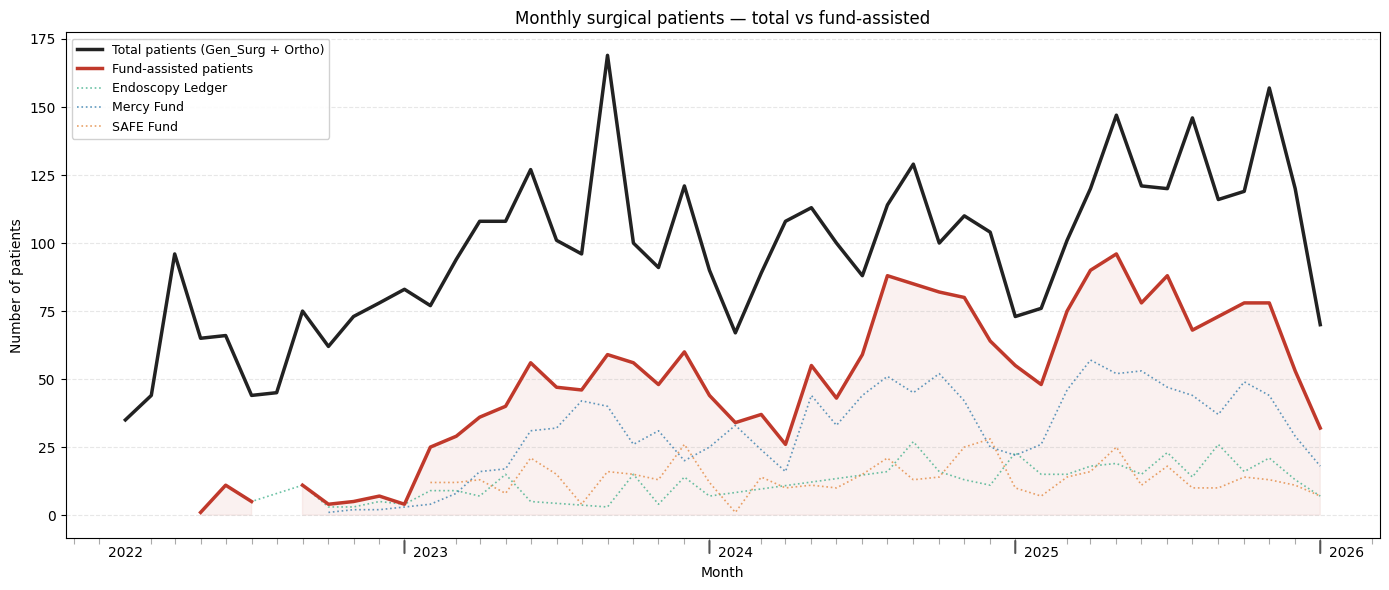

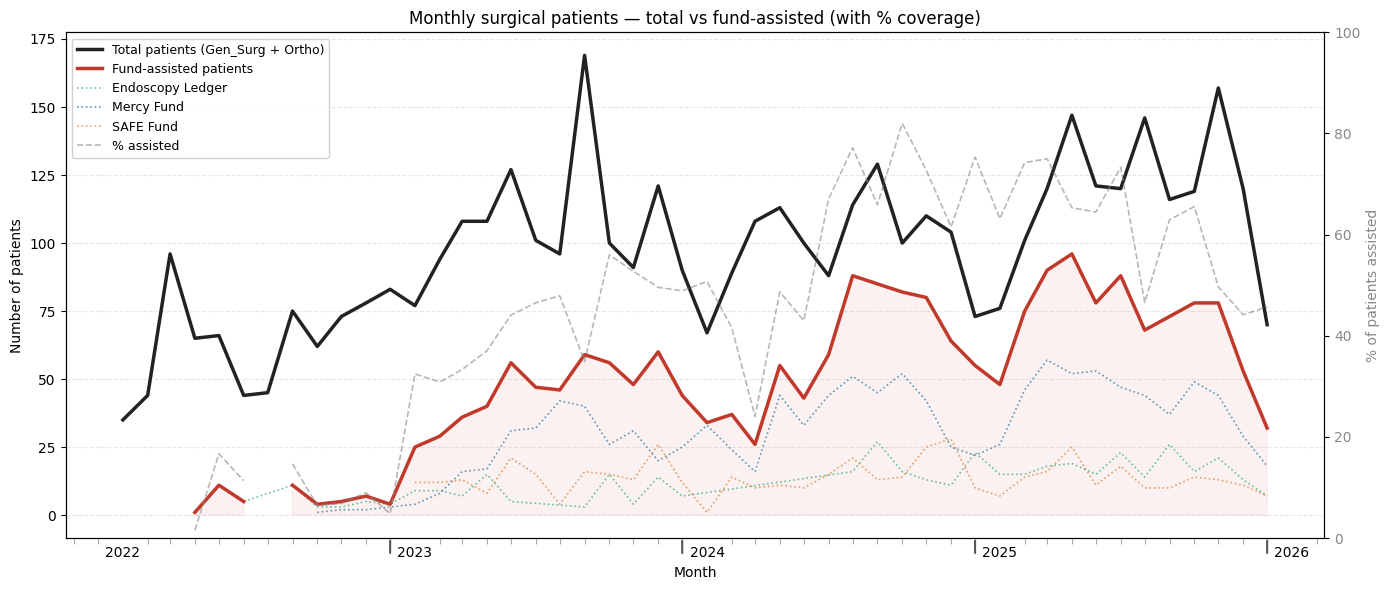

In [14]:
def build_fig(show_pct: bool):
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax2 = ax1.twinx() if show_pct else None

    colors = {"mercy": "#1d6fa4", "endo": "#2ca87f", "safe": "#e07b2a"}
    labels = {"mercy": "Mercy Fund", "endo": "Endoscopy Ledger", "safe": "SAFE Fund"}

    # Total patients
    ax1.plot(summary["month_dt"], summary["total_patients"],
             color="#222222", linewidth=2.5,
             label="Total patients (Gen_Surg + Ortho)", zorder=5)

    # Fund-assisted patients
    ax1.plot(summary["month_dt"], summary["assisted_patients"],
             color="#c0392b", linewidth=2.5,
             label="Fund-assisted patients", zorder=5)
    ax1.fill_between(summary["month_dt"], summary["assisted_patients"],
                     alpha=0.07, color="#c0392b")

    # Per-fund breakdown
    for fund, grp in fund_counts.groupby("fund"):
        grp = grp.sort_values("month_dt")
        ax1.plot(grp["month_dt"], grp["n_patients"],
                 color=colors[fund], linewidth=1.2, linestyle=":",
                 alpha=0.7, label=labels[fund], zorder=3)

    # Percentage line — only in the second plot
    if show_pct:
        ax2.plot(summary["month_dt"], summary["pct_assisted"],
                 color="#888888", linewidth=1.2, linestyle="--",
                 alpha=0.6, label="% assisted", zorder=2)
        ax2.set_ylabel("% of patients assisted", color="#888888", fontsize=10)
        ax2.tick_params(axis="y", labelcolor="#888888")
        ax2.set_ylim(0, 100)

    # X-axis formatting
    ax1.xaxis.set_minor_locator(MonthLocator())
    ax1.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax1.tick_params(axis='x', which='minor', length=4, width=0.8, color='#aaaaaa')
    ax1.xaxis.set_major_locator(YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax1.tick_params(axis='x', which='major', length=0, labelsize=10, pad=6)

    dec_dates = [d for d in summary["month_dt"] if d.month == 12]
    
    # Convert december dates to axis coordinates for manual tick drawing
    ax1.figure.canvas.draw()  # needed to resolve transforms
    for d in dec_dates:
        x = ax1.xaxis.convert_units(d)
        ax1.annotate('', xy=(x, 0), xycoords=('data', 'axes fraction'),
                     xytext=(x, -0.035), textcoords=('data', 'axes fraction'),
                     annotation_clip=False,
                     arrowprops=dict(arrowstyle='-', color='#555555', lw=1.5))

    # Labels & legend
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Number of patients")
    title = "Monthly surgical patients — total vs fund-assisted"
    ax1.set_title(title + (" (with % coverage)" if show_pct else ""))
    ax1.grid(axis="y", linestyle="--", alpha=0.3)

    lines1, labs1 = ax1.get_legend_handles_labels()
    if show_pct:
        lines2, labs2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labs1 + labs2,
                   loc="upper left", fontsize=9, framealpha=0.9)
    else:
        ax1.legend(lines1, labs1, loc="upper left", fontsize=9, framealpha=0.9)

    fig.autofmt_xdate(rotation=0, ha='center')
    plt.tight_layout()
    return fig


fig_plain = build_fig(show_pct=False)
fig_pct   = build_fig(show_pct=True)

fig_plain.savefig("poor_patient_plots/monthly_patients_coverage.png",     dpi=150)
fig_plain.savefig("poor_patient_plots/monthly_patients_coverage.pdf")

fig_pct.savefig("poor_patient_plots/monthly_patients_coverage_pct.png",   dpi=150)
fig_pct.savefig("poor_patient_plots/monthly_patients_coverage_pct.pdf")

plt.show()